# RavenStack SaaS Churn Prediction

**Pipeline:** Raw data → customer-level features → churn label → train/test split → Logistic Regression / Random Forest / XGBoost → best model → churn probability → Low / Medium / High risk → Power BI

**Leakage rule:** `ravenstack_churn_events.csv`, subscription `churn_flag` and `end_date` are never used as features, because they only exist *after* a customer churns.

Requires: `pip install pandas numpy scikit-learn xgboost shap matplotlib`

In [4]:
import json, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, RocCurveDisplay, average_precision_score,
                             confusion_matrix, f1_score, precision_recall_curve,
                             precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import (GridSearchCV, RepeatedStratifiedKFold, StratifiedKFold,
                                     cross_val_predict, cross_val_score, train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
%matplotlib inline

SEED = 42
DATA = Path(r"S:\Projects\GITHUB\Data Analytics\Projects\SaaS Churn & Revenue-at-Risk Analytics\Dataset")            # folder containing the CSVs
OUT = Path("outputs")       # where results are saved
OUT.mkdir(exist_ok=True)
REF_DATE = pd.Timestamp("2024-12-31")   # end of the observation window

## 1. Load data
The churn events table is deliberately **not** loaded: reason code, refund amount, feedback text and churn date are only known after churn (target leakage).

In [5]:
acc = pd.read_csv(DATA / "ravenstack_accounts.csv", parse_dates=["signup_date"])
sub = pd.read_csv(DATA / "ravenstack_subscriptions.csv", parse_dates=["start_date"])
use = pd.read_csv(DATA / "ravenstack_feature_usage.csv")
tix = pd.read_csv(DATA / "ravenstack_support_tickets.csv")
print(acc.shape, sub.shape, use.shape, tix.shape)

(500, 10) (5000, 14) (25000, 8) (2000, 9)


## 2. Customer-level feature engineering (one row per account)
Dropped on purpose: subscription `churn_flag` (the outcome itself), `end_date` (only set once a subscription ends), `arr_amount` (exactly 12 × MRR).

In [6]:
sub = sub.sort_values(["account_id", "start_date"])
sub["plan_change"] = (sub.upgrade_flag | sub.downgrade_flag).astype(int)
sub["annual"] = (sub.billing_frequency == "annual").astype(int)

f_sub = sub.groupby("account_id").agg(
    n_subscriptions=("subscription_id", "size"),
    avg_mrr=("mrr_amount", "mean"),
    max_mrr=("mrr_amount", "max"),
    latest_mrr=("mrr_amount", "last"),
    annual_billing_share=("annual", "mean"),
    auto_renew_share=("auto_renew_flag", "mean"),
    trial_sub_share=("is_trial", "mean"),
    n_upgrades=("upgrade_flag", "sum"),
    n_downgrades=("downgrade_flag", "sum"),
    n_plan_changes=("plan_change", "sum"),
    first_sub_start=("start_date", "min"),
)
f_sub["subscription_tenure_days"] = (REF_DATE - f_sub.pop("first_sub_start")).dt.days

use = use.merge(sub[["subscription_id", "account_id"]], on="subscription_id", how="left")
f_use = use.groupby("account_id").agg(
    usage_events=("usage_id", "size"),
    total_usage_count=("usage_count", "sum"),
    total_errors=("error_count", "sum"),
    avg_session_secs=("usage_duration_secs", "mean"),
    distinct_features_used=("feature_name", "nunique"),
    beta_usage_share=("is_beta_feature", "mean"),
)
f_use["error_rate"] = f_use.total_errors / f_use.total_usage_count.clip(lower=1)

tix["urgent"] = tix.priority.isin(["urgent", "high"]).astype(int)
f_tix = tix.groupby("account_id").agg(
    ticket_count=("ticket_id", "size"),
    avg_first_response_min=("first_response_time_minutes", "mean"),
    avg_resolution_hours=("resolution_time_hours", "mean"),
    avg_satisfaction=("satisfaction_score", "mean"),
    escalation_count=("escalation_flag", "sum"),
    high_priority_share=("urgent", "mean"),
)

df = acc.set_index("account_id").join([f_sub, f_use, f_tix])
df["company_size_seats"] = df.seats
df["account_age_days"] = (REF_DATE - df.signup_date).dt.days
df["is_trial"] = df.is_trial.astype(int)

# no tickets / no usage -> counts are genuinely 0; averages stay NaN (imputed in the pipeline)
for c in ["ticket_count", "escalation_count", "usage_events", "total_usage_count", "total_errors"]:
    df[c] = df[c].fillna(0)
df["escalation_rate"] = df.escalation_count / df.ticket_count.replace(0, np.nan)
df.head()

,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag,n_subscriptions,...,error_rate,ticket_count,avg_first_response_min,avg_resolution_hours,avg_satisfaction,escalation_count,high_priority_share,company_size_seats,account_age_days,escalation_rate
account_id,,,,,,,,,,,,,,,,,,,,,
A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,0,False,10,...,0.071028,2.0,91.000000,23.000000,3.000000,0.0,1.000000,9,76,0.000000
A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,0,True,8,...,0.039437,3.0,73.333333,38.000000,4.000000,0.0,0.666667,18,502,0.000000
A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,0,False,15,...,0.058465,3.0,63.666667,43.666667,4.666667,0.0,0.333333,1,126,0.000000
A-1f0ac7,Company_3,HealthTech,UK,2023-08-27,other,Basic,24,1,False,7,...,0.054974,2.0,174.000000,29.000000,NaN,0.0,0.500000,24,492,0.000000
A-ce550d,Company_4,HealthTech,US,2024-10-27,event,Enterprise,35,0,True,9,...,0.053541,7.0,107.857143,42.285714,3.800000,1.0,0.571429,35,65,0.142857


## 3. Target and feature lists
`Churn = 1` → churned, `Churn = 0` → retained.

In [7]:
y = df.churn_flag.astype(int)
CAT = ["plan_tier", "industry", "country", "referral_source"]
NUM = ["company_size_seats", "is_trial", "account_age_days",
       "n_subscriptions", "avg_mrr", "max_mrr", "latest_mrr", "annual_billing_share",
       "auto_renew_share", "trial_sub_share", "n_upgrades", "n_downgrades",
       "n_plan_changes", "subscription_tenure_days",
       "usage_events", "total_usage_count", "total_errors", "error_rate",
       "avg_session_secs", "distinct_features_used", "beta_usage_share",
       "ticket_count", "avg_first_response_min", "avg_resolution_hours",
       "avg_satisfaction", "escalation_count", "escalation_rate", "high_priority_share"]
X = df[CAT + NUM]
print(f"Accounts: {len(X)} | features: {X.shape[1]} | churn rate: {y.mean():.1%}")

Accounts: 500 | features: 32 | churn rate: 22.0%


## 4. Train / test split
Stratified 80/20. One row per account, so no account can appear on both sides. The test set is used once, at the end.

In [8]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.20, stratify=y, random_state=SEED)
print(X_tr.shape, X_te.shape, "| test churners:", y_te.sum())

(400, 32) (100, 32) | test churners: 22


## 5. Models and model selection
Imputers, scalers and encoders live **inside** the pipeline so they are fit on training folds only. Each model is tuned with 5-fold CV, then compared with 5×3 repeated stratified CV, all on training data only.

In [9]:
def preprocessor(scale: bool):
    num_steps = [("impute", SimpleImputer(strategy="median", add_indicator=True))]
    if scale:
        num_steps.append(("scale", StandardScaler()))
    return ColumnTransformer(
        [("num", Pipeline(num_steps), NUM),
         ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT)],
        verbose_feature_names_out=False)

pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()
candidates = {
    "Logistic Regression": (
        Pipeline([("prep", preprocessor(True)),
                  ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED))]),
        {"clf__C": [0.01, 0.03, 0.1, 0.3, 1.0]}),
    "Random Forest": (
        Pipeline([("prep", preprocessor(False)),
                  ("clf", RandomForestClassifier(n_estimators=400, class_weight="balanced_subsample",
                                                 random_state=SEED, n_jobs=-1))]),
        {"clf__max_depth": [3, 5, 8], "clf__min_samples_leaf": [5, 10, 20]}),
    "XGBoost": (
        Pipeline([("prep", preprocessor(False)),
                  ("clf", XGBClassifier(scale_pos_weight=pos_weight, eval_metric="logloss",
                                        subsample=0.8, colsample_bytree=0.8,
                                        random_state=SEED, n_jobs=-1))]),
        {"clf__max_depth": [2, 3], "clf__n_estimators": [100, 250],
         "clf__learning_rate": [0.03, 0.1], "clf__min_child_weight": [3, 8]}),
}

inner = StratifiedKFold(5, shuffle=True, random_state=SEED)
rep = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=SEED)
tuned, cv_rows = {}, []
for name, (pipe, grid) in candidates.items():
    gs = GridSearchCV(pipe, grid, scoring="roc_auc", cv=inner, n_jobs=-1).fit(X_tr, y_tr)
    tuned[name] = gs.best_estimator_
    aucs = cross_val_score(gs.best_estimator_, X_tr, y_tr, scoring="roc_auc", cv=rep, n_jobs=-1)
    cv_rows.append({"model": name, "best_params": str(gs.best_params_),
                    "cv_roc_auc_mean": aucs.mean(), "cv_roc_auc_std": aucs.std()})
cv_df = pd.DataFrame(cv_rows).sort_values("cv_roc_auc_mean", ascending=False)
best_name = cv_df.iloc[0]["model"]
best = tuned[best_name]
print("Best model by CV ROC-AUC:", best_name)
cv_df.round(3)

Best model by CV ROC-AUC: Random Forest


,model,best_params,cv_roc_auc_mean,cv_roc_auc_std
1,Random Forest,"{'clf__max_depth': 8, 'clf__min_samples_leaf':...",0.486,0.088
2,XGBoost,"{'clf__learning_rate': 0.1, 'clf__max_depth': ...",0.478,0.054
0,Logistic Regression,{'clf__C': 0.01},0.452,0.075


## 6. Decision threshold
Chosen from **out-of-fold predictions on the training set** (max F1), never from the test set.

In [10]:
def pick_threshold(est):
    oof = cross_val_predict(est, X_tr, y_tr, cv=inner, method="predict_proba")[:, 1]
    p_, r_, t_ = precision_recall_curve(y_tr, oof)
    return float(t_[np.argmax((2 * p_ * r_ / (p_ + r_ + 1e-12))[:-1])])

threshold = pick_threshold(best)
print(f"Decision threshold for {best_name}: {threshold:.3f}")

Decision threshold for Random Forest: 0.230


## 7. Hold-out test evaluation
Precision, recall, F1, ROC-AUC and PR-AUC for all three models. The PR-AUC baseline equals the churn rate.

In [11]:
rows, test_proba = [], {}
for name, est in tuned.items():
    th = pick_threshold(est)
    est.fit(X_tr, y_tr)
    p = est.predict_proba(X_te)[:, 1]
    test_proba[name] = p
    pred = (p >= th).astype(int)
    rows.append({"model": name, "threshold": th,
                 "precision": precision_score(y_te, pred, zero_division=0),
                 "recall": recall_score(y_te, pred),
                 "f1": f1_score(y_te, pred),
                 "roc_auc": roc_auc_score(y_te, p),
                 "pr_auc": average_precision_score(y_te, p)})
test_df = pd.DataFrame(rows).set_index("model").round(3)
print(f"Test n = {len(y_te)}, churners = {y_te.sum()}, baseline PR-AUC = {y_te.mean():.3f}")
test_df

Test n = 100, churners = 22, baseline PR-AUC = 0.220


,threshold,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
Logistic Regression,0.260,0.22,1.0,0.361,0.621,0.339
Random Forest,0.230,0.22,1.0,0.361,0.579,0.336
XGBoost,0.023,0.22,1.0,0.361,0.602,0.331


[[ 0 78]
 [ 0 22]]


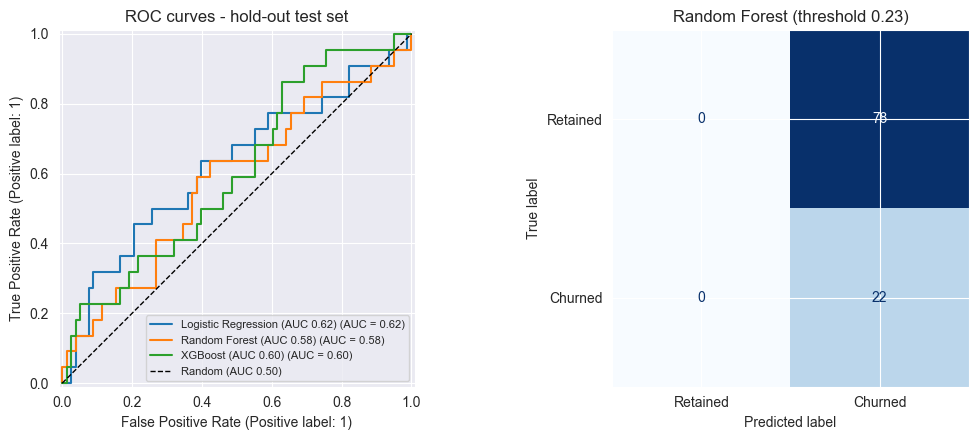

In [12]:
best_pred = (test_proba[best_name] >= threshold).astype(int)
cm = confusion_matrix(y_te, best_pred)
print(cm)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for name, p in test_proba.items():
    RocCurveDisplay.from_predictions(y_te, p, name=f"{name} (AUC {roc_auc_score(y_te, p):.2f})", ax=axes[0])
axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="Random (AUC 0.50)")
axes[0].set_title("ROC curves - hold-out test set"); axes[0].legend(loc="lower right", fontsize=8)
ConfusionMatrixDisplay(cm, display_labels=["Retained", "Churned"]).plot(ax=axes[1], cmap="Blues", colorbar=False)
axes[1].set_title(f"{best_name} (threshold {threshold:.2f})")
plt.tight_layout(); fig.savefig(OUT / "roc_and_confusion.png", dpi=150); plt.show()

## 8. Explainability (SHAP)

avg_mrr                     0.0186
avg_first_response_min      0.0161
error_rate                  0.0148
avg_session_secs            0.0121
subscription_tenure_days    0.0094
distinct_features_used      0.0087
account_age_days            0.0078
trial_sub_share             0.0076
beta_usage_share            0.0070
industry_DevTools           0.0070
Name: mean_abs_shap, dtype: float64

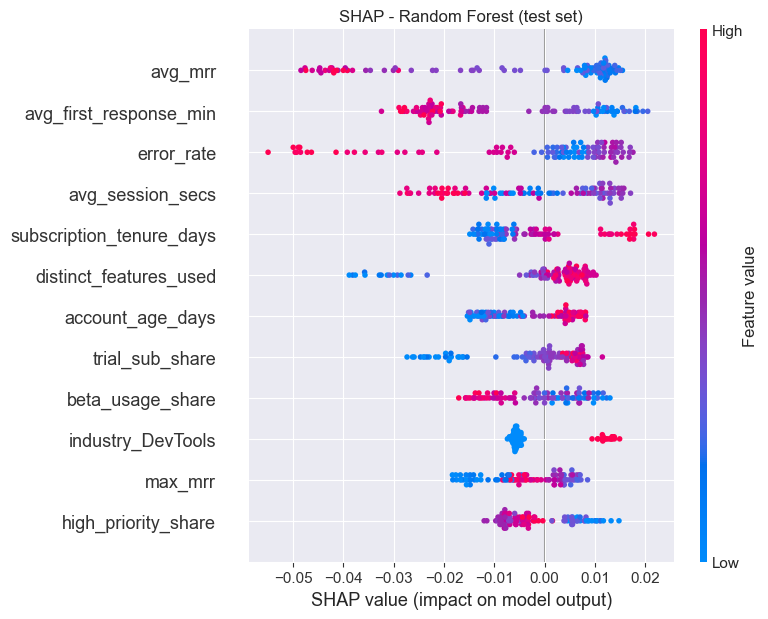

In [13]:
prep, clf = best.named_steps["prep"], best.named_steps["clf"]
Xt = pd.DataFrame(prep.transform(X_te), columns=prep.get_feature_names_out())
if best_name == "Logistic Regression":
    sv = shap.LinearExplainer(clf, prep.transform(X_tr)).shap_values(Xt)
else:
    sv = shap.TreeExplainer(clf).shap_values(Xt)
    if isinstance(sv, list):
        sv = sv[1]
    elif getattr(sv, "ndim", 2) == 3:
        sv = sv[:, :, 1]

shap_imp = (pd.Series(np.abs(sv).mean(0), index=Xt.columns)
              .sort_values(ascending=False).rename("mean_abs_shap"))
shap_imp.to_csv(OUT / "feature_importance_shap.csv")
display(shap_imp.head(10).round(4))
shap.summary_plot(sv, Xt, max_display=12, show=False)
plt.title(f"SHAP - {best_name} (test set)"); plt.tight_layout(); plt.show()

## 9. Churn probability and risk segmentation (for Power BI)
Scores are **out-of-fold** for every account (each account is scored by a model that never saw it). Segments: bottom 50% = Low, next 30% = Medium, top 20% = High.

In [14]:
oof_all = cross_val_predict(best, X, y, cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
                            method="predict_proba")[:, 1]
q50, q80 = np.quantile(oof_all, [0.50, 0.80])
risk = pd.cut(oof_all, [-np.inf, q50, q80, np.inf], labels=["Low", "Medium", "High"])

scores = pd.DataFrame({"account_id": X.index, "churn_probability": oof_all.round(4),
                       "risk_segment": risk, "actual_churn": y.values})
scores = scores.merge(df[["account_name", "plan_tier", "industry", "country", "latest_mrr", "avg_mrr"]]
                      .reset_index(), on="account_id")
scores["revenue_at_risk_mrr"] = np.where(scores.risk_segment == "High", scores.latest_mrr, 0)
scores.to_csv(OUT / "churn_risk_scores.csv", index=False)

tier = scores.groupby("risk_segment", observed=True).agg(
    accounts=("account_id", "size"), actual_churn_rate=("actual_churn", "mean"),
    avg_prob=("churn_probability", "mean")).round(3)
overall_auc = roc_auc_score(y, oof_all)
print("Out-of-fold ROC-AUC, all accounts:", round(overall_auc, 3))
tier

Out-of-fold ROC-AUC, all accounts: 0.536


,accounts,actual_churn_rate,avg_prob
risk_segment,,,
Low,250,0.200,0.385
Medium,150,0.233,0.464
High,100,0.250,0.534


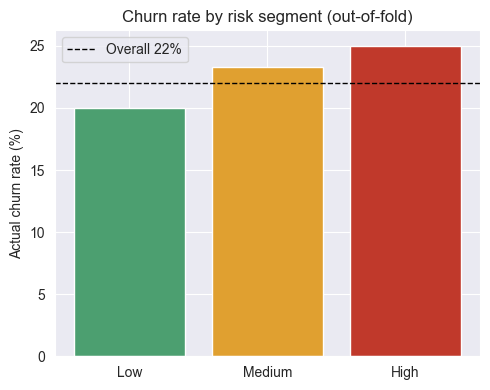

In [15]:
t = tier.reindex(["Low", "Medium", "High"])
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(t.index, t.actual_churn_rate * 100, color=["#4C9F70", "#E0A030", "#C0392B"])
ax.axhline(y.mean() * 100, color="k", ls="--", lw=1, label=f"Overall {y.mean():.0%}")
ax.set_ylabel("Actual churn rate (%)"); ax.set_title("Churn rate by risk segment (out-of-fold)")
ax.legend(); plt.tight_layout(); fig.savefig(OUT / "risk_segments.png", dpi=150); plt.show()

test_df.to_csv(OUT / "model_comparison_test.csv")
cv_df.to_csv(OUT / "model_comparison_cv.csv", index=False)
with open(OUT / "results_summary.json", "w") as f:
    json.dump({"best_model": best_name, "threshold": threshold, "churn_rate": float(y.mean()),
               "oof_roc_auc_all_accounts": float(overall_auc), "confusion_matrix": cm.tolist(),
               "test_metrics": test_df.to_dict("index"),
               "risk_segments": tier.to_dict("index")}, f, indent=2, default=float)

## 10. Conclusion


On the RavenStack dataset, none of the three models (Logistic Regression, Random Forest, XGBoost) predicted churn better than chance. Cross-validated ROC-AUC was 0.45 to 0.49 for all of them, where 0.50 means random guessing. The hold-out set has only 22 churners, so its higher AUCs (up to 0.62) are noise.

The risk segments barely separated: actual churn was 20% in Low, 23% in Medium and 25% in High. At the F1-optimal threshold the models flagged every account as churned (recall 1.00, precision 0.22, the base churn rate).

To rule out a modelling mistake, I tried subscription-level churn and a time-based H2 2024 label (AUC 0.51 to 0.55), and a model trained on shuffled labels scored 0.48. Leakage was controlled throughout.

The churn flag appears to be unrelated to the usage, support and billing columns, so there is no signal for a model to learn. This is a limitation of the dataset, not of the method. These scores should not be used to target retention spend. The reliable insights from this data are descriptive: churn by industry, country and referral source, and revenue at risk.

